In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/competitions/vinbigdata-chest-xray-abnormalities-detection/sample_submission.csv
/kaggle/input/competitions/vinbigdata-chest-xray-abnormalities-detection/train.csv
/kaggle/input/competitions/vinbigdata-chest-xray-abnormalities-detection/test/83caa8a85e03606cf57e49147d7ac569.dicom
/kaggle/input/competitions/vinbigdata-chest-xray-abnormalities-detection/test/7550347fa2bb96c2354a3716dfa3a69c.dicom
/kaggle/input/competitions/vinbigdata-chest-xray-abnormalities-detection/test/74b23792db329cff5843e36efb8aa65a.dicom
/kaggle/input/competitions/vinbigdata-chest-xray-abnormalities-detection/test/94568a546be103177cb582d3e91cd2d8.dicom
/kaggle/input/competitions/vinbigdata-chest-xray-abnormalities-detection/test/6da36354fc904b63bc03eb3884e0c35c.dicom
/kaggle/input/competitions/vinbigdata-chest-xray-abnormalities-detection/test/5b3620a56668010877cfafa9322e18b5.dicom
/kaggle/input/competitions/vinbigdata-chest-xray-abnormalities-detection/test/5157d5c9b1f0004b29310652ea54e825.dicom
/ka

KeyboardInterrupt: 

In [2]:
import os

print(os.listdir("/kaggle/input"))

['competitions']


In [3]:
import os

print(os.listdir("/kaggle/input/competitions"))

['vinbigdata-chest-xray-abnormalities-detection']


In [4]:
base_path = "/kaggle/input/competitions/vinbigdata-chest-xray-abnormalities-detection"

print(os.listdir(base_path))

['sample_submission.csv', 'train.csv', 'test', 'train']


In [5]:
print(os.listdir(base_path + "/train")[:5])

['4d390e07733ba06e5ff07412f09c0a92.dicom', '289f69f6462af4933308c275d07060f0.dicom', '68335ee73e67706aa59b8b55b54b11a4.dicom', '7ecd6f67f649f26c05805c8359f9e528.dicom', '2229148faa205e881cf0d932755c9e40.dicom']


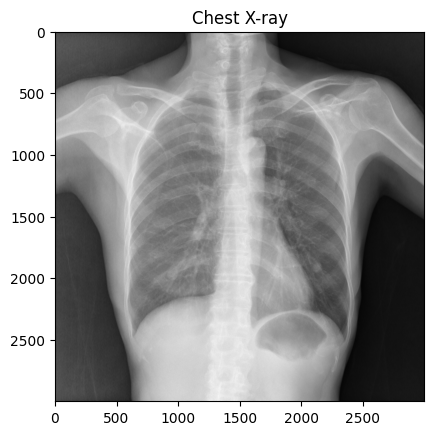

In [6]:
sample_path = base_path + "/train/4d390e07733ba06e5ff07412f09c0a92.dicom"  

import pydicom
import matplotlib.pyplot as plt

ds = pydicom.dcmread(sample_path)

plt.imshow(ds.pixel_array, cmap="gray")
plt.title("Chest X-ray")
plt.show()

In [7]:
import torch
import pydicom
import pandas as pd
import cv2

print("Torch:", torch.__version__)
print("CUDA Available:", torch.cuda.is_available())
print("Environment Ready 🚀")

Torch: 2.9.0+cpu
CUDA Available: False
Environment Ready 🚀


In [8]:
import os

base_path = "/kaggle/input/competitions/vinbigdata-chest-xray-abnormalities-detection"
train_path = base_path + "/train"

os.makedirs("/kaggle/working/images/train", exist_ok=True)

print("Paths ready ✅")

Paths ready ✅


DICOM-> JPG CONVERSION 

In [1]:
import os
import pydicom
import cv2
import numpy as np
from tqdm import tqdm

# ===== PATHS =====
TRAIN_DICOM_PATH = "/kaggle/input/competitions/vinbigdata-chest-xray-abnormalities-detection/train"
IMAGE_SAVE_PATH = "/kaggle/working/images/train"

# Create output folder if not exists
os.makedirs(IMAGE_SAVE_PATH, exist_ok=True)

# Get all DICOM file names
image_files = [f for f in os.listdir(TRAIN_DICOM_PATH) if f.endswith(".dicom")]

print(f"Total images found: {len(image_files)}")

# ===== CONVERSION LOOP =====
for idx, file_name in enumerate(tqdm(image_files)):

    image_id = file_name.replace(".dicom", "")
    dicom_path = os.path.join(TRAIN_DICOM_PATH, file_name)
    save_path = os.path.join(IMAGE_SAVE_PATH, image_id + ".jpg")

    # Skip if already converted (safe re-run)
    if os.path.exists(save_path):
        continue

    try:
        dicom = pydicom.dcmread(dicom_path)
        image = dicom.pixel_array.astype(np.float32)

        # Normalize to 0–255
        image = (image - image.min()) / (image.max() - image.min() + 1e-6)
        image = (image * 255).astype(np.uint8)

        # Resize (optional but recommended for training speed)
        image = cv2.resize(image, (1024, 1024))

        # Save as compressed JPG (storage safe)
        cv2.imwrite(save_path, image, [cv2.IMWRITE_JPEG_QUALITY, 85])

        # Progress log every 2000 images
        if (idx + 1) % 2000 == 0:
            print(f"{idx + 1} images processed...")

    except Exception as e:
        print(f"Error processing {image_id}: {e}")

print("✅ DICOM → JPG conversion completed.")


Total images found: 15000


 13%|█▎        | 2000/15000 [37:22<5:46:04,  1.60s/it] 

2000 images processed...


 27%|██▋       | 4000/15000 [1:12:19<2:32:54,  1.20it/s]

4000 images processed...


...

12000 images processed...


 93%|█████████▎| 14000/15000 [4:07:31<15:51,  1.05it/s]  

14000 images processed...


100%|██████████| 15000/15000 [4:24:24<00:00,  1.06s/it]

✅ DICOM → JPG conversion completed.


In [ ]:
REMOVING NO FINDING 

In [5]:
# ===== MASTER PATH CONFIG =====
BASE_PATH = "/kaggle/input/competitions/vinbigdata-chest-xray-abnormalities-detection"

TRAIN_DICOM_PATH = BASE_PATH + "/train"
CSV_PATH = BASE_PATH + "/train.csv"

IMAGE_SAVE_PATH = "/kaggle/working/images/train"
LABEL_SAVE_PATH = "/kaggle/working/labels/train"

import os
os.makedirs(IMAGE_SAVE_PATH, exist_ok=True)
os.makedirs(LABEL_SAVE_PATH, exist_ok=True)

print("Paths configured successfully ✅")

Paths configured successfully ✅


In [6]:
import pandas as pd

df = pd.read_csv(CSV_PATH)

# Remove "No finding"
df = df[df["class_id"] != 14]

print("Remaining annotations:", len(df))
df.head()

Remaining annotations: 36096


,image_id,class_name,class_id,rad_id,x_min,y_min,x_max,y_max
2,9a5094b2563a1ef3ff50dc5c7ff71345,Cardiomegaly,3,R10,691.0,1375.0,1653.0,1831.0
3,051132a778e61a86eb147c7c6f564dfe,Aortic enlargement,0,R10,1264.0,743.0,1611.0,1019.0
5,1c32170b4af4ce1a3030eb8167753b06,Pleural thickening,11,R9,627.0,357.0,947.0,433.0
6,0c7a38f293d5f5e4846aa4ca6db4daf1,ILD,5,R17,1347.0,245.0,2188.0,2169.0
7,47ed17dcb2cbeec15182ed335a8b5a9e,Nodule/Mass,8,R9,557.0,2352.0,675.0,2484.0


**CSV TO YOLO**

In [7]:
import cv2
from tqdm import tqdm

grouped = df.groupby("image_id")

for image_id, group in tqdm(grouped):

    img_path = IMAGE_SAVE_PATH + "/" + image_id + ".jpg"

    if not os.path.exists(img_path):
        continue

    img = cv2.imread(img_path)
    h, w, _ = img.shape

    label_path = LABEL_SAVE_PATH + "/" + image_id + ".txt"

    with open(label_path, "w") as f:
        for _, row in group.iterrows():

            class_id = int(row["class_id"])

            x_min = row["x_min"]
            y_min = row["y_min"]
            x_max = row["x_max"]
            y_max = row["y_max"]

            x_center = ((x_min + x_max) / 2) / w
            y_center = ((y_min + y_max) / 2) / h
            box_width = (x_max - x_min) / w
            box_height = (y_max - y_min) / h

            f.write(f"{class_id} {x_center} {y_center} {box_width} {box_height}\n")

print("YOLO labels generated for full dataset ✅")

100%|██████████| 4394/4394 [00:37<00:00, 117.74it/s]

YOLO labels generated for full dataset ✅


In [8]:
len(os.listdir(LABEL_SAVE_PATH))

4394

ZIPPING FILE 

In [9]:
import os
import shutil

# Create structured dataset folder
os.makedirs("/kaggle/working/vinbig_yolo/images", exist_ok=True)
os.makedirs("/kaggle/working/vinbig_yolo/labels", exist_ok=True)

# Move images and labels inside
shutil.move("/kaggle/working/images/train", "/kaggle/working/vinbig_yolo/images/train")
shutil.move("/kaggle/working/labels/train", "/kaggle/working/vinbig_yolo/labels/train")

print("Structured folder created ✅")

Structured folder created ✅


In [ ]:
!zip -r vinbig_images.zip /kaggle/working/vinbig_yolo/images
!zip -r vinbig_labels.zip /kaggle/working/vinbig_yolo/labels

  adding: kaggle/working/vinbig_yolo/images/ (stored 0%)
  adding: kaggle/working/vinbig_yolo/images/train/ (stored 0%)
  adding: kaggle/working/vinbig_yolo/images/train/38d59aef0ecbc73f365767bc09692283.jpg (deflated 0%)
  adding: kaggle/working/vinbig_yolo/images/train/59f163522f9e49ab143f88d3febb8a33.jpg (deflated 1%)
  adding: kaggle/working/vinbig_yolo/images/train/8c0185c222f81cd07d085edfc65aa416.jpg (deflated 0%)
  adding: kaggle/working/vinbig_yolo/images/train/305c85dddfdddac905f288a8106ca371.jpg (deflated 1%)
  adding: kaggle/working/vinbig_yolo/images/train/993adb8e17f2726e4c9bb5cb414d9de5.jpg (deflated 1%)
  adding: kaggle/working/vinbig_yolo/images/train/8a8dfb35de1667ab00b27caf1d4b61df.jpg (deflated 0%)
  adding: kaggle/working/vinbig_yolo/images/train/4ff991b63e0c4eebea3961bb2702acc7.jpg (deflated 3%)
  adding: kaggle/working/vinbig_yolo/images/train/b4a7269d3fcbed43638a44892088ac4a.jpg (deflated 1%)
  adding: kaggle/working/vinbig_yolo/images/train/2cc0b399d0813d6cfefc15

In [12]:
!ls -lh /kaggle/working

total 2.3G
drwxr-xr-x 2 root root 4.0K Feb 27 18:50 images
drwxr-xr-x 2 root root 4.0K Feb 27 18:50 labels
-rw-r--r-- 1 root root 1.6G Feb 27 18:53 vinbig_images.zip
-rw-r--r-- 1 root root 1.9M Feb 27 18:53 vinbig_labels.zip
drwxr-xr-x 4 root root 4.0K Feb 27 18:50 vinbig_yolo
-rw-r--r-- 1 root root 779M Feb 27 18:51 vinbig_yolo_dataset.zip
